In [1]:
from race_env import RaceEnv
from stable_baselines3 import PPO
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

req         WARNING 	DEFAULT CACHE ENABLED! (103.85 MB) C:\Users\charl\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Barcelona Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['44

0.3596218830469732
0.8274781461483005


In [2]:
# Load selected agent

model = PPO.load("RL_model_final")

In [3]:
# Code simulates 1 race with the selected agent then saves the lap by lap data to csv called strategy_output

env = RaceEnv()

obs, _ = env.reset()
done = False
records = []

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    records.append(info)
    done = terminated or truncated

strategy_df = pd.DataFrame(records)
strategy_df.to_csv("strategy_output.csv", index=False)

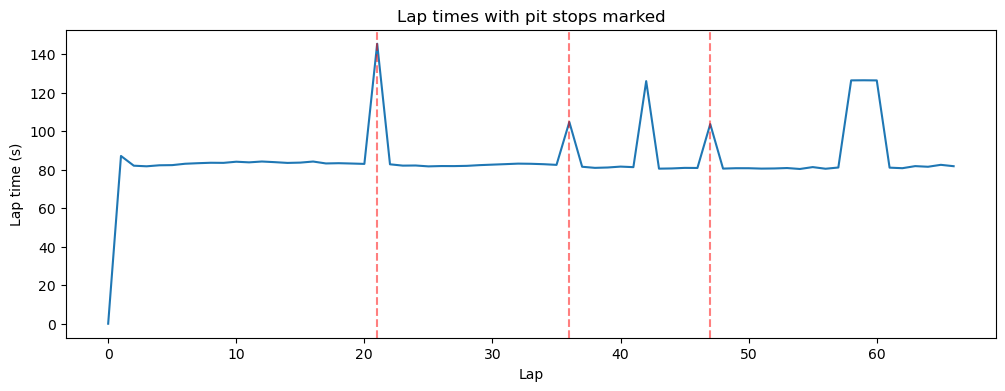

In [4]:
# Plots each lap time and marks pitstops

plt.figure(figsize=(12, 4))
plt.plot(strategy_df["lap"], strategy_df["lap_time"])
for pit_lap_num in strategy_df[strategy_df["pitted"] == True]["lap"]:
    plt.axvline(pit_lap_num, color="red", linestyle="--", alpha=0.5)
plt.xlabel("Lap")
plt.ylabel("Lap time (s)")
plt.title("Lap times with pit stops marked")
plt.show()

In [8]:
# Simulates 10 races and outputs each simulation total race time and average race time across the 10 races

n_simulations = 10

race_times = []
all_lap_times = []
all_pit_laps = []

for sim in range(n_simulations):
    env = RaceEnv()
    obs, info = env.reset()
    done = False

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = env.step(action)

   
    race_times.append(env.total_time)
    all_lap_times.append(env.lap_times)
    all_pit_laps.append(env.pit_laps)


race_times = np.array(race_times)


avg_time = race_times.mean()

print(f"Simulated {n_simulations} races")
print(f"Average race time: {avg_time:.2f} seconds\n")

# Print each race time
for i, t in enumerate(race_times, start=1):
    print(f"Race {i}: {t:.2f} seconds")

Simulated 10 races
Average race time: 5640.91 seconds

Race 1: 5530.47 seconds
Race 2: 5630.46 seconds
Race 3: 5623.25 seconds
Race 4: 5610.08 seconds
Race 5: 5578.27 seconds
Race 6: 5755.11 seconds
Race 7: 5762.41 seconds
Race 8: 5533.75 seconds
Race 9: 5671.82 seconds
Race 10: 5713.49 seconds
